# hrc_dtfstats

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


In [2]:
download_chandra_obsid 3698 evt2,dtf
mv -f 3698/primary/*.fits.gz .
gunzip -f *fits.gz
/bin/rm -rf 3698


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  evt2     fits       22 Mb  ####################          < 1 s  70590.6 kb/s
  dtf      fits       75 Kb  ####################          < 1 s  7839.1 kb/s
  dtf      fits        4 Kb  ####################          < 1 s  579.7 kb/s

      Total download size for ObsId 3698 = 22 Mb
      Total download time for ObsId 3698 = < 1 s



In [3]:
dmkeypar hrcf03698_000N004_dtf1.fits ASCDSVER echo+

8.4.5


In [4]:
dmcopy "hrcf03698N004_evt2.fits[time=164259750:164261850]" filter_evt2.fits clob+


In [5]:
dmlist hrcf03698N004_evt2.fits  header,clean | egrep '^DTCOR|^ONTIME|^LIVETIME|^EXPOSURE'

ONTIME                    5171.3814679682 [s]       
DTCOR                    0.755343479530             Dead time correction
LIVETIME                  3906.1692719921           Ontime multiplied by DTCOR
EXPOSURE                  3906.1692719921           Total exposure time, with all known corr. appl.


In [6]:
dmlist filter_evt2.fits header,clean | egrep '^DTCOR|^ONTIME|^LIVETIME|^EXPOSURE'

ONTIME                    2100.0 [s]                
DTCOR                    0.755343479530             Dead time correction
LIVETIME                  1586.2213070130           Ontime multiplied by DTCOR
EXPOSURE                  1586.2213070130           Total exposure time, with all known corr. appl.


## Examine dtfs

In [7]:
dmstat "hrcf03698_000N004_dtf1.fits[cols dtf]" 

DTF
    min:	0 	      @:	1 
    max:	1 	      @:	2 
   mean:	0.76564416062 
  sigma:	0.270005164 
    sum:	2081.0208286 
   good:	2718 
   null:	0 



In [8]:
pget dmstat out_mean

0.76564416062


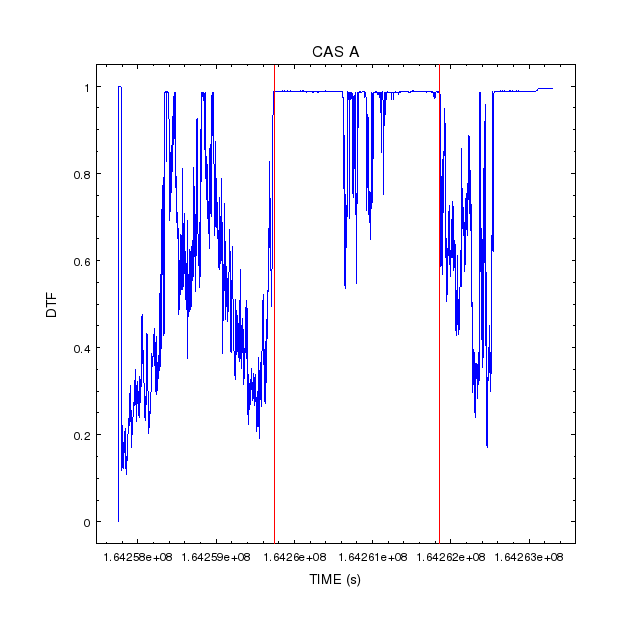

In [9]:
cat << EOM > c1.py
make_figure("hrcf03698_000N004_dtf1.fits[cols time,dtf]", "line.color=blue symbol.style=none")
add_vline(164259750, "color=red")
add_vline(164261850, "color=red")
print_window("chips_01.png","export.clobber=True")
quit()
EOM

chips -n c1.py
display < chips_01.png



## Recompute stats

In [10]:
pset hrc_dtfstats infile=hrcf03698_000N004_dtf1.fits
pset hrc_dtfstats outfile=dtf.stats
pset hrc_dtfstats gtifile=filter_evt2.fits
hrc_dtfstats mode=h clob+

In [11]:
dmlist dtf.stats"[cols DTCOR]" data,clean

#  DTCOR
     0.96380777655308


## Update evt file

In [12]:
dmhedit filter_evt2.fits file= op=add key=DTCOR value=0.963807

### or 

In [13]:
dmkeypar dtf.stats DTCOR
dmhedit filter_evt2.fits file= op=add key=DTCOR value=")dmkeypar.value"

In [14]:
dmkeypar filter_evt2.fits DTCOR echo+

0.96380777655308


## Recompute time keywords

In [15]:
dmcopy filter_evt2.fits"[time=:]" dtcorr_evt2.fits clob+

## Check diffs


In [16]:
dmdiff filter_evt2.fits dtcorr_evt2.fits data=no comments=no

Infile 1:  filter_evt2.fits
Infile 2:  dtcorr_evt2.fits

-----------------------
HEADER VALUE DIFFERENCES
-----------------------


Message:                                Keyword:              Value(s):                    Diff:
--------                                 -------              ---------                    -----
Values are not equal                    CHECKSUM EYmdHYldEYldEYld  ZJ9OhG7NZG7NfG7N
Values are not equal                     HISTNUM              485  492                        +7
Values are not equal                    LIVETIME   1586.221307013  2023.9963307615      +437.775
Values are not equal                    EXPOSURE   1586.221307013  2023.9963307615      +437.775

--------------------------
SUBSPACE VALUE DIFFERENCES
--------------------------

Message:                         Column:       Row              Value(s):                    Diff:
--------                         -------       ---              ---------                    -----
# dmdiff (CIAO 4.9